<a href="https://colab.research.google.com/github/FatiBuuloloo/Automated_Support_Ticket_Triage_and_Intelligent_Priority_Scoring-mini_project-009/blob/main/classifying_queue_and_priority.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install sentence-transformers

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

In [ ]:
url = "https://github.com/FatiBuuloloo/Automated_Support_Tickets_Priority/releases/download/v1.0.0/customer_support_tickets_translated+labeling.csv"
data = pd.read_csv(url)
data.shape

(28587, 11)

In [ ]:
data.head(5)

,body,answer,type,queue,priority,language,version,tag_1,body_en,sentiment_label,sentiment_score
0,"Sehr geehrtes Support-Team, ich möchte einen ...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,"Dear Support Team, I would like to report a se...",negative,0.740054
1,"Dear Customer Support Team, I am writing to r...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,"Dear Customer Support Team, I am writing to r...",negative,0.810550
2,"Dear Customer Support Team, I hope this messa...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,"Dear Customer Support Team, I hope this messa...",positive,0.629225
3,"Dear Customer Support Team, I hope this messa...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,"Dear Customer Support Team, I hope this messa...",neutral,0.629057
4,"Dear Support Team, I hope this message reache...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,"Dear Support Team, I hope this message reache...",positive,0.664589


In [ ]:
data.columns.tolist()

['body',
 'answer',
 'type',
 'queue',
 'priority',
 'language',
 'version',
 'tag_1',
 'body_en',
 'sentiment_label',
 'sentiment_score']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   body             28587 non-null  object 
 1   answer           28580 non-null  object 
 2   type             28587 non-null  object 
 3   queue            28587 non-null  object 
 4   priority         28587 non-null  object 
 5   language         28587 non-null  object 
 6   version          28587 non-null  int64  
 7   tag_1            28587 non-null  object 
 8   body_en          28587 non-null  object 
 9   sentiment_label  28587 non-null  object 
 10  sentiment_score  28587 non-null  float64
dtypes: float64(1), int64(1), object(9)
memory usage: 2.4+ MB


In [ ]:
model = SentenceTransformer('all-mpnet-base-v2')
embeddings = model.encode(data["body_en"].tolist(), show_progress_bar=True)

In [ ]:
df_embeddings = pd.DataFrame(embeddings)
df_embeddings.to_csv("df_embeddings.csv",index="False")

# Training model for Classifying Queue

In [ ]:
url1 = "https://github.com/FatiBuuloloo/Automated_Support_Tickets_Priority/releases/download/v1.0.0/df_embeddings.csv"
data1 = pd.read_csv(url1)
data1.columns

Index(['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '758', '759', '760', '761', '762', '763', '764', '765', '766', '767'],
      dtype='object', length=769)

In [ ]:
data1.drop("Unnamed: 0",axis=1,inplace=True)

In [ ]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=2, weights='distance', metric="manhattan"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1,class_weight='balanced'),
    "Naive Bayes": GaussianNB(),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.01, random_state=42,class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.01, random_state=42, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(iterations=100, learning_rate=0.01, depth=8, random_state=42, verbose=0, auto_class_weights='Balanced'),
    "MLP": MLPClassifier(hidden_layer_sizes=(120,80),max_iter=100,activation="relu",solver="adam",random_state=42),
    "Balanced Random Forest": BalancedRandomForestClassifier(n_estimators=700,min_samples_leaf=2, sampling_strategy="auto")
    }

In [ ]:
le = LabelEncoder()
df_X = data1
df_y = data["queue"]
df_y_encoded = le.fit_transform(df_y)
train_X,test_X,train_y,test_y = train_test_split(df_X,df_y_encoded, test_size= 0.25,shuffle=True, stratify=df_y_encoded)


Classification Report KNN model:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       697
           1       0.77      0.76      0.77      1067
           2       0.79      0.74      0.77       101
           3       0.85      0.83      0.84       144
           4       0.80      0.84      0.82       858
           5       0.80      0.79      0.79      1313
           6       0.79      0.79      0.79       359
           7       0.74      0.76      0.75       230
           8       0.82      0.83      0.82       287
           9       0.85      0.84      0.85      2091

    accuracy                           0.81      7147
   macro avg       0.81      0.80      0.80      7147
weighted avg       0.81      0.81      0.81      7147



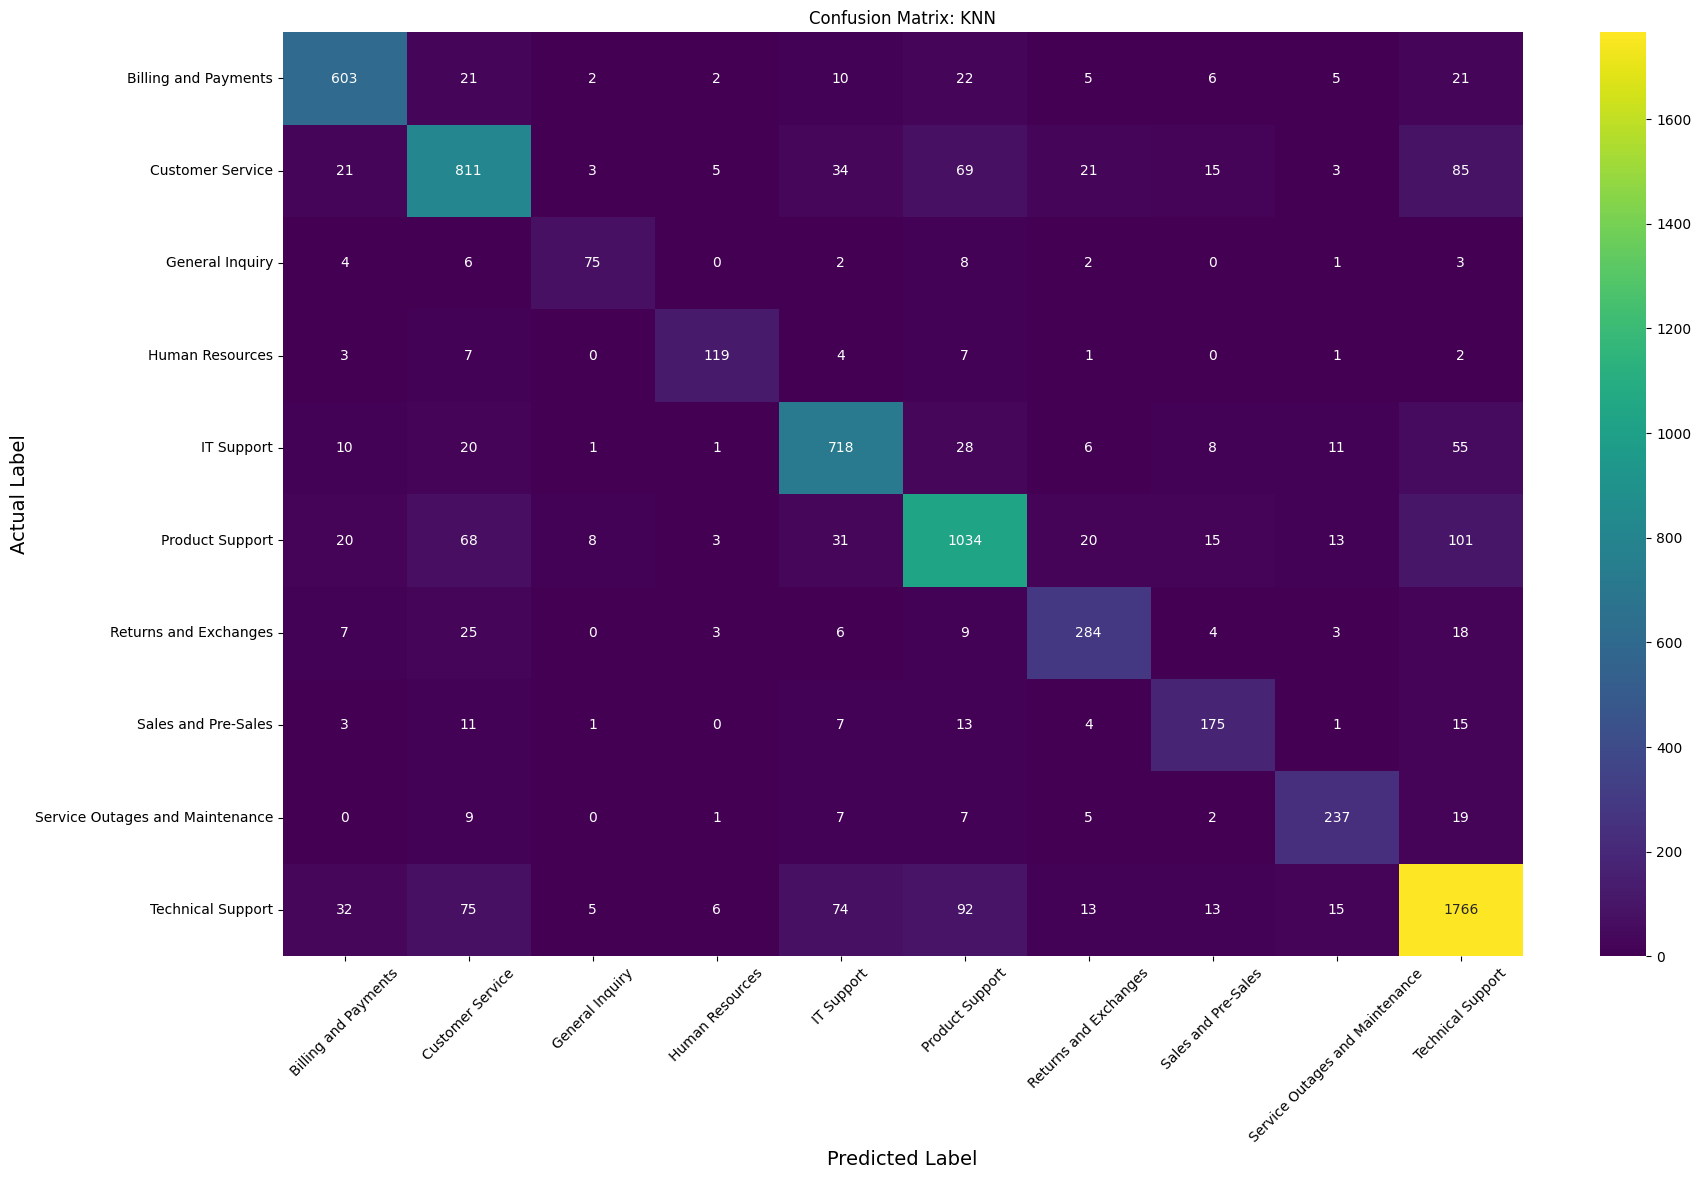


Classification Report Random Forest model:
              precision    recall  f1-score   support

           0       0.91      0.63      0.74       697
           1       0.33      0.39      0.36      1067
           2       0.51      0.48      0.49       101
           3       0.77      0.49      0.60       144
           4       0.69      0.32      0.44       858
           5       0.54      0.27      0.36      1313
           6       0.41      0.40      0.41       359
           7       0.17      0.64      0.26       230
           8       0.44      0.65      0.53       287
           9       0.52      0.62      0.57      2091

    accuracy                           0.47      7147
   macro avg       0.53      0.49      0.48      7147
weighted avg       0.54      0.47      0.48      7147



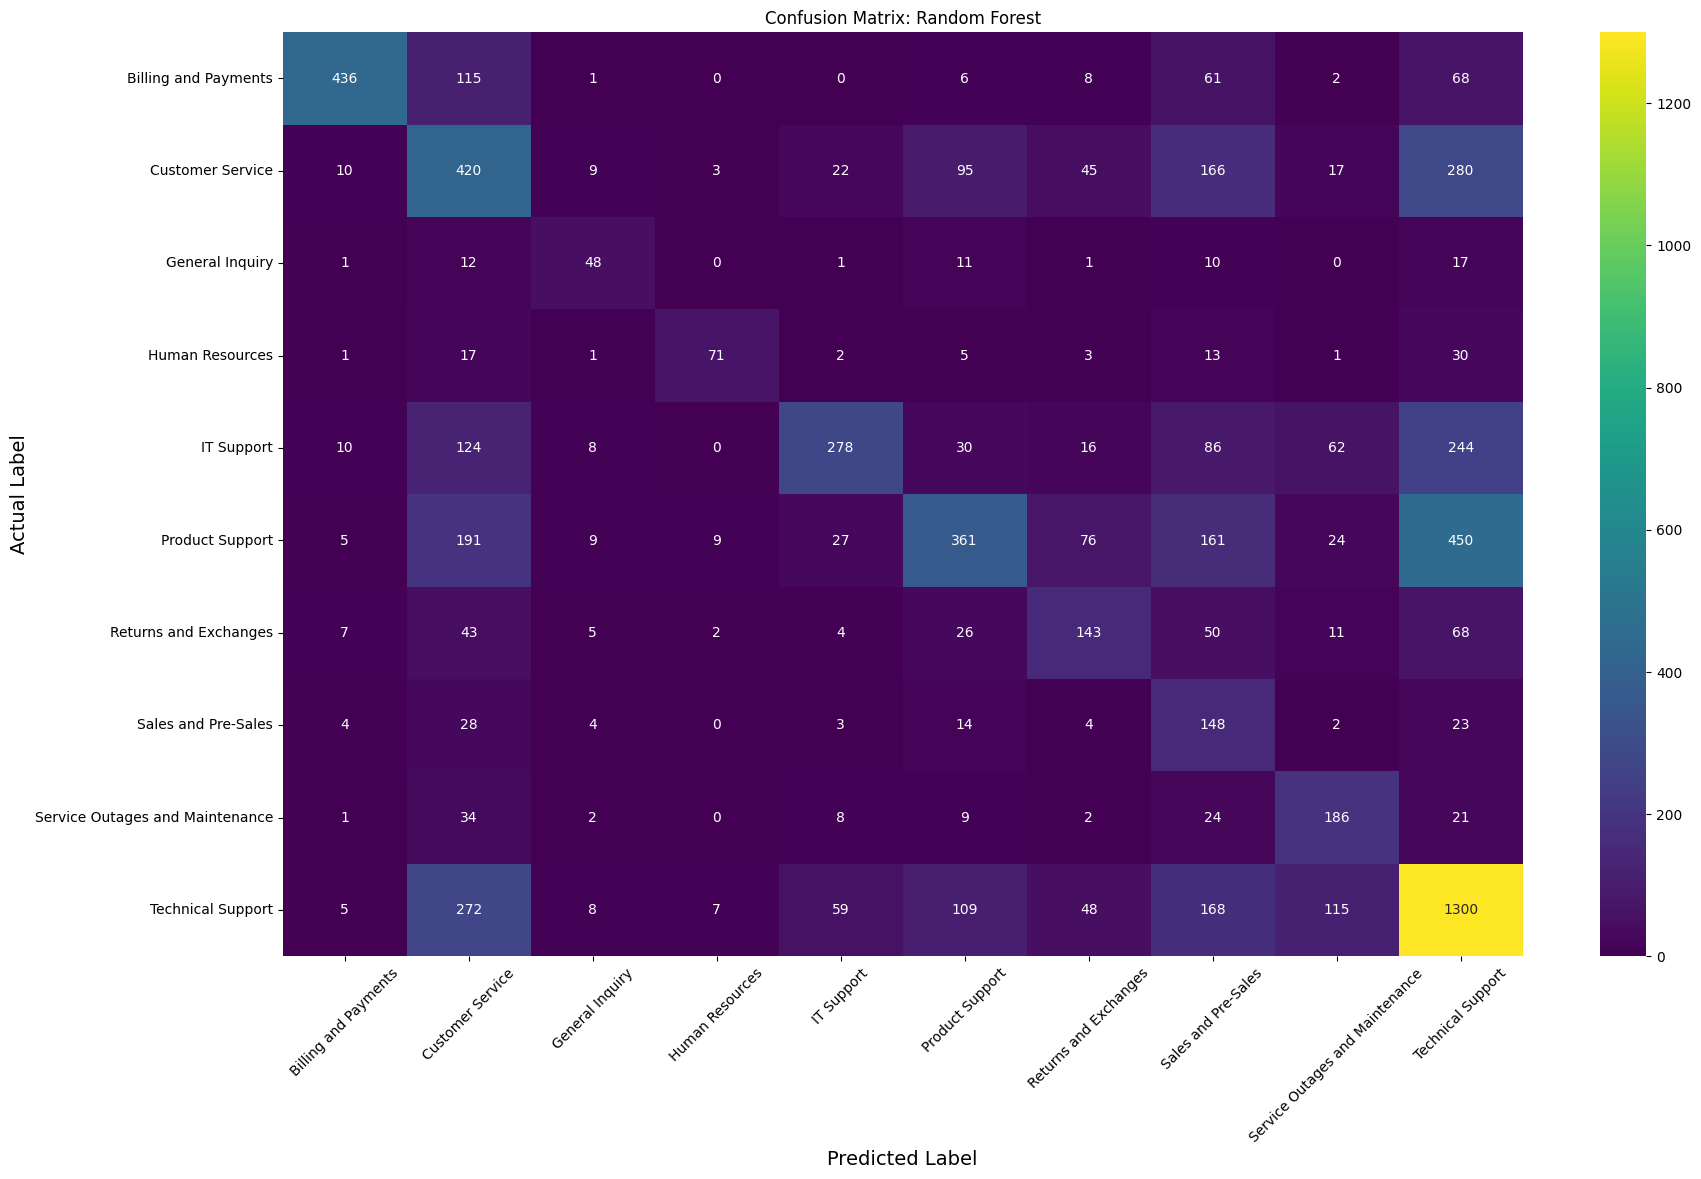


Classification Report Naive Bayes model:
              precision    recall  f1-score   support

           0       0.96      0.56      0.71       697
           1       0.23      0.19      0.21      1067
           2       0.04      0.24      0.08       101
           3       0.06      0.31      0.11       144
           4       0.25      0.07      0.11       858
           5       0.30      0.05      0.08      1313
           6       0.23      0.19      0.21       359
           7       0.09      0.55      0.16       230
           8       0.20      0.64      0.31       287
           9       0.48      0.36      0.41      2091

    accuracy                           0.27      7147
   macro avg       0.28      0.32      0.24      7147
weighted avg       0.38      0.27      0.28      7147



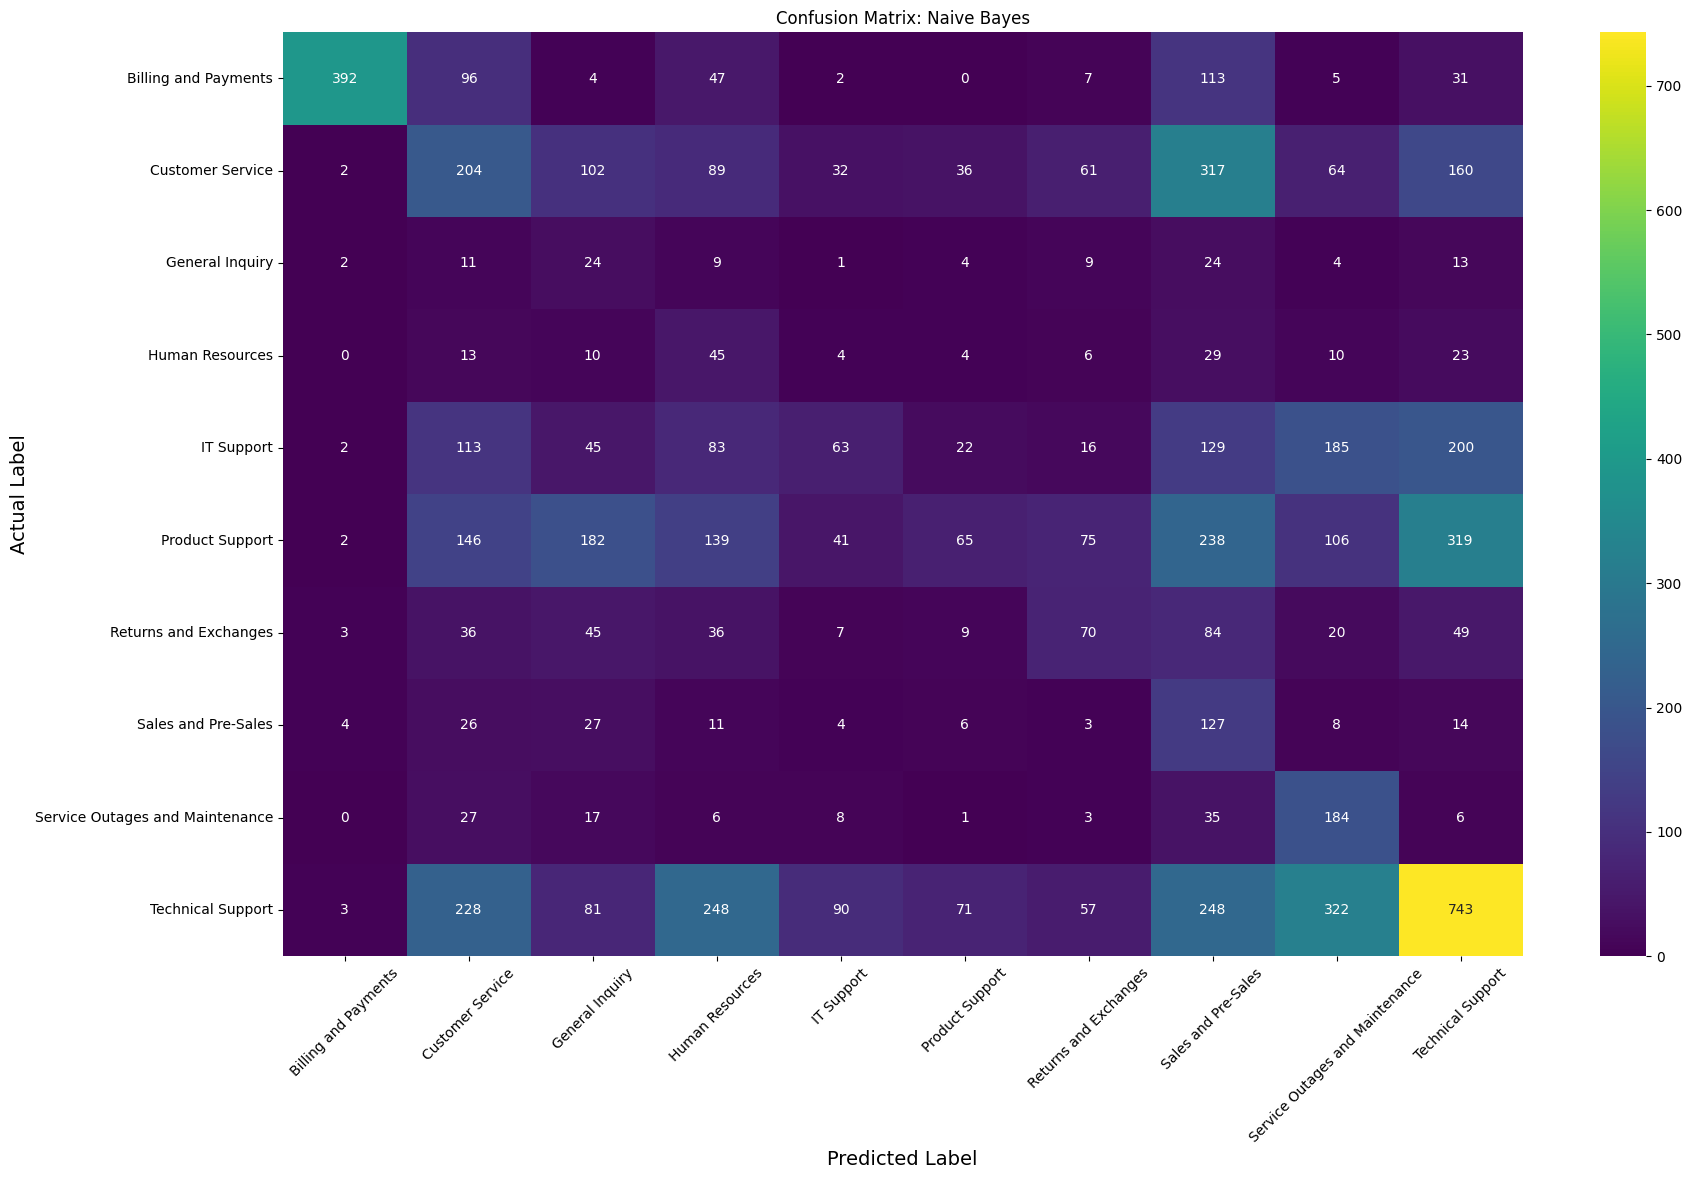

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.458975 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 21440, number of used features: 768
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585

Classification Report LightGBM model:
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       697
           1       0

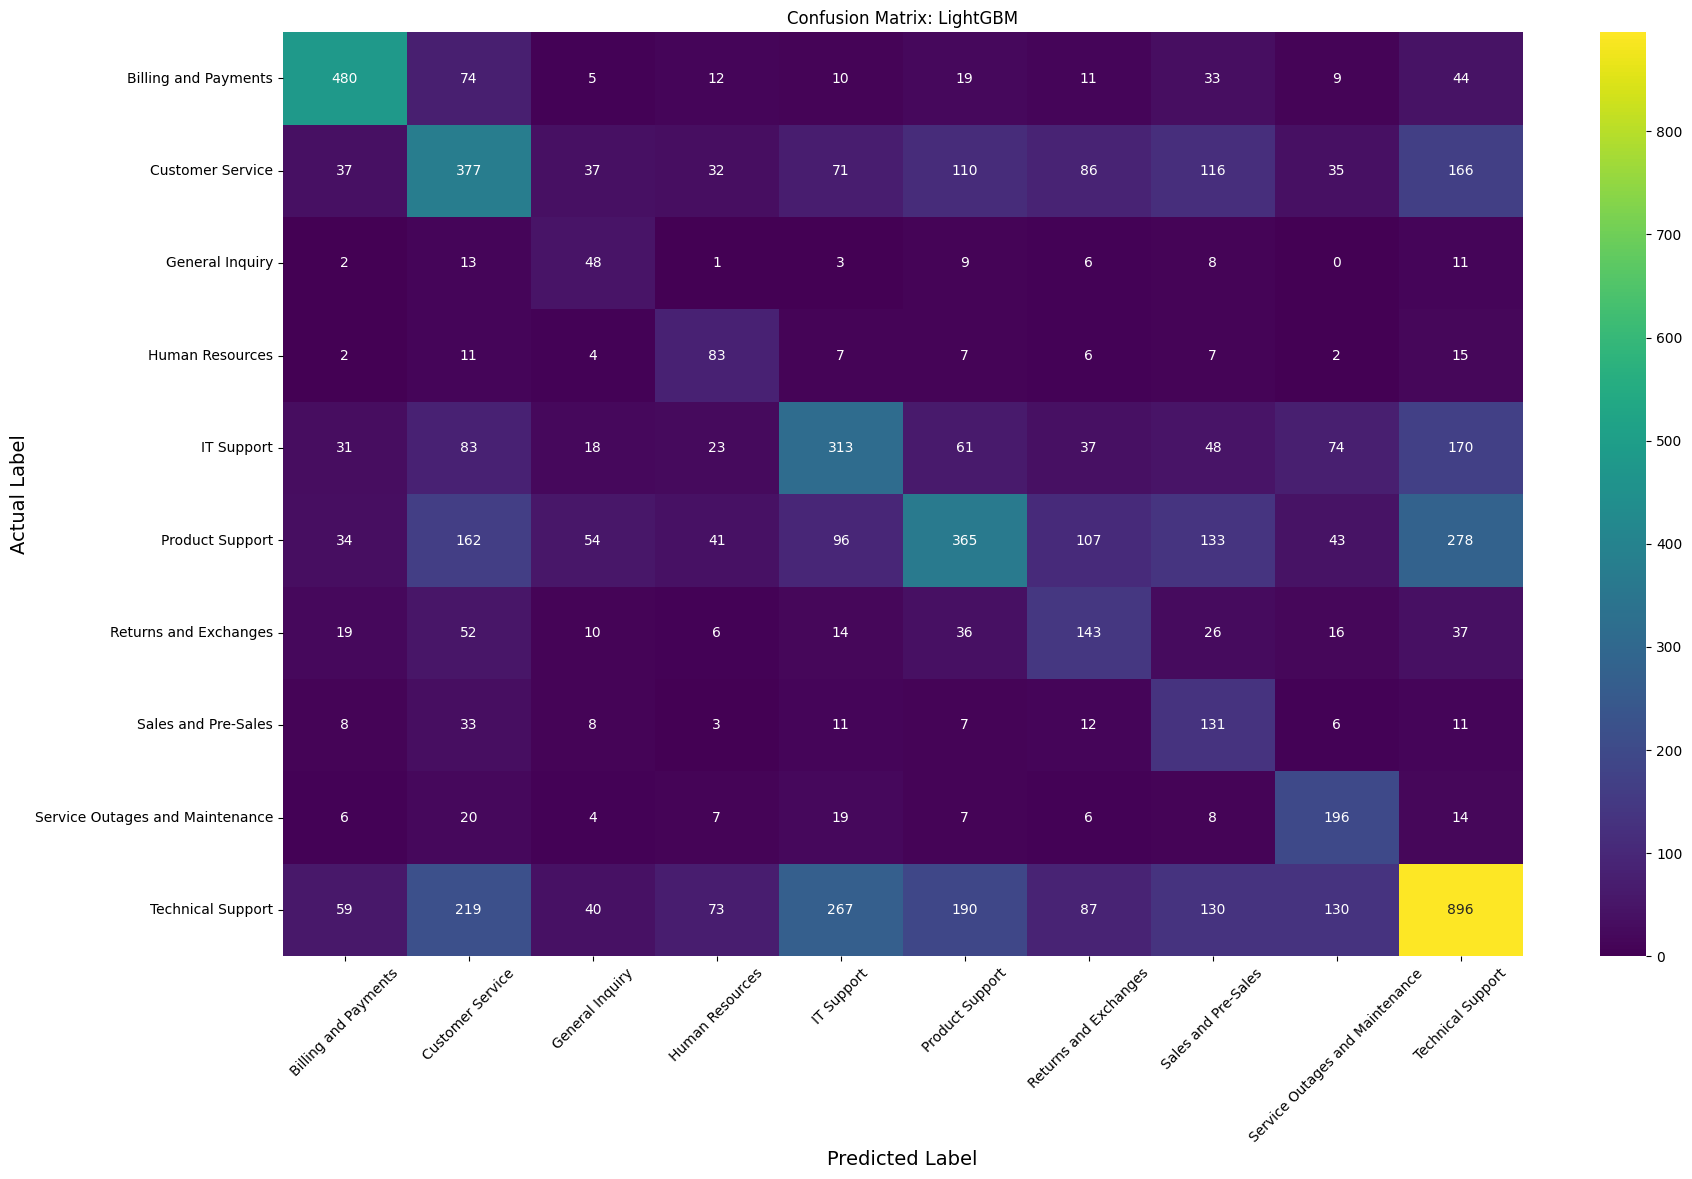


Classification Report XGBoost model:
              precision    recall  f1-score   support

           0       0.97      0.56      0.71       697
           1       0.42      0.10      0.16      1067
           2       0.00      0.00      0.00       101
           3       1.00      0.03      0.07       144
           4       1.00      0.00      0.01       858
           5       0.52      0.14      0.22      1313
           6       0.82      0.05      0.09       359
           7       0.67      0.01      0.02       230
           8       0.89      0.22      0.35       287
           9       0.33      0.97      0.50      2091

    accuracy                           0.39      7147
   macro avg       0.66      0.21      0.21      7147
weighted avg       0.59      0.39      0.30      7147



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


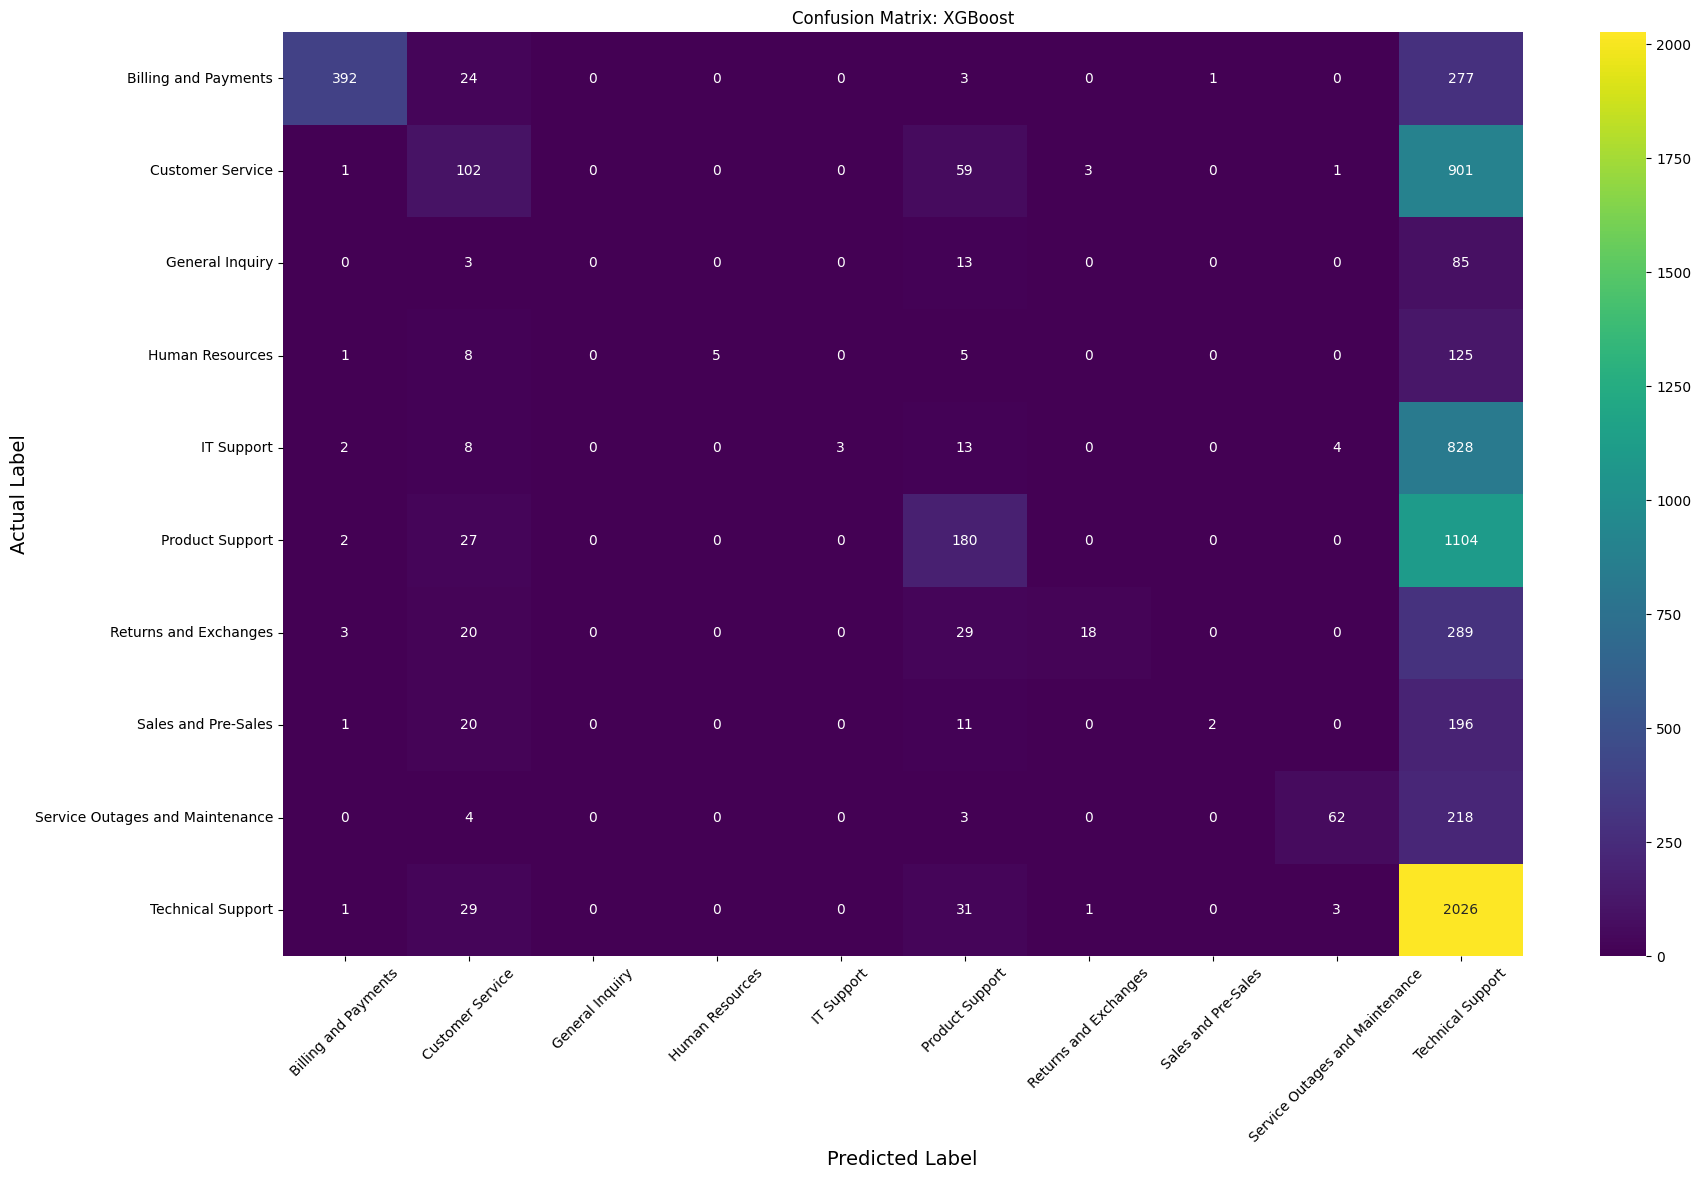


Classification Report CatBoost model:
              precision    recall  f1-score   support

           0       0.83      0.60      0.70       697
           1       0.32      0.21      0.25      1067
           2       0.09      0.54      0.16       101
           3       0.15      0.52      0.24       144
           4       0.43      0.17      0.24       858
           5       0.42      0.09      0.15      1313
           6       0.21      0.27      0.23       359
           7       0.11      0.63      0.19       230
           8       0.22      0.67      0.33       287
           9       0.51      0.38      0.44      2091

    accuracy                           0.32      7147
   macro avg       0.33      0.41      0.29      7147
weighted avg       0.43      0.32      0.33      7147



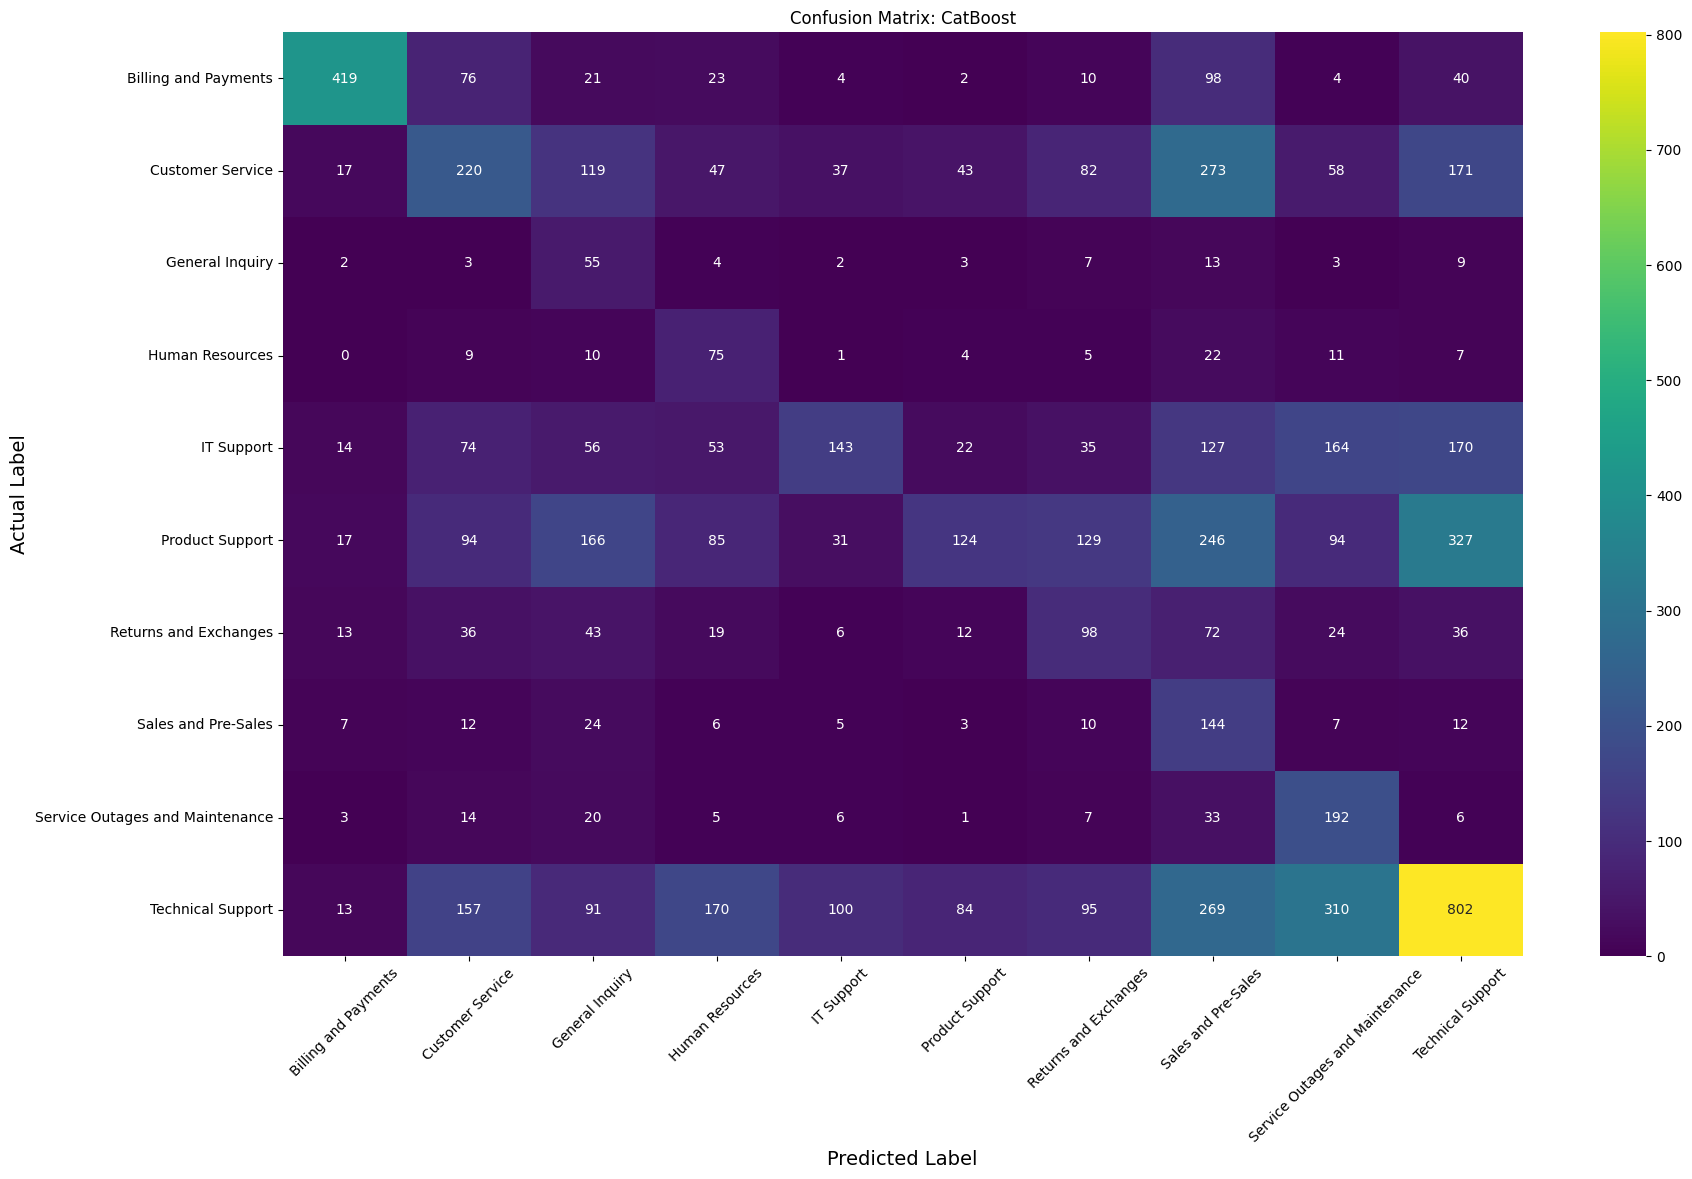

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



Classification Report MLP model:
              precision    recall  f1-score   support

           0       0.72      0.81      0.77       697
           1       0.60      0.52      0.56      1067
           2       0.50      0.46      0.48       101
           3       0.44      0.59      0.50       144
           4       0.52      0.62      0.56       858
           5       0.61      0.57      0.59      1313
           6       0.56      0.50      0.53       359
           7       0.52      0.50      0.51       230
           8       0.62      0.69      0.66       287
           9       0.68      0.66      0.67      2091

    accuracy                           0.62      7147
   macro avg       0.58      0.59      0.58      7147
weighted avg       0.62      0.62      0.62      7147



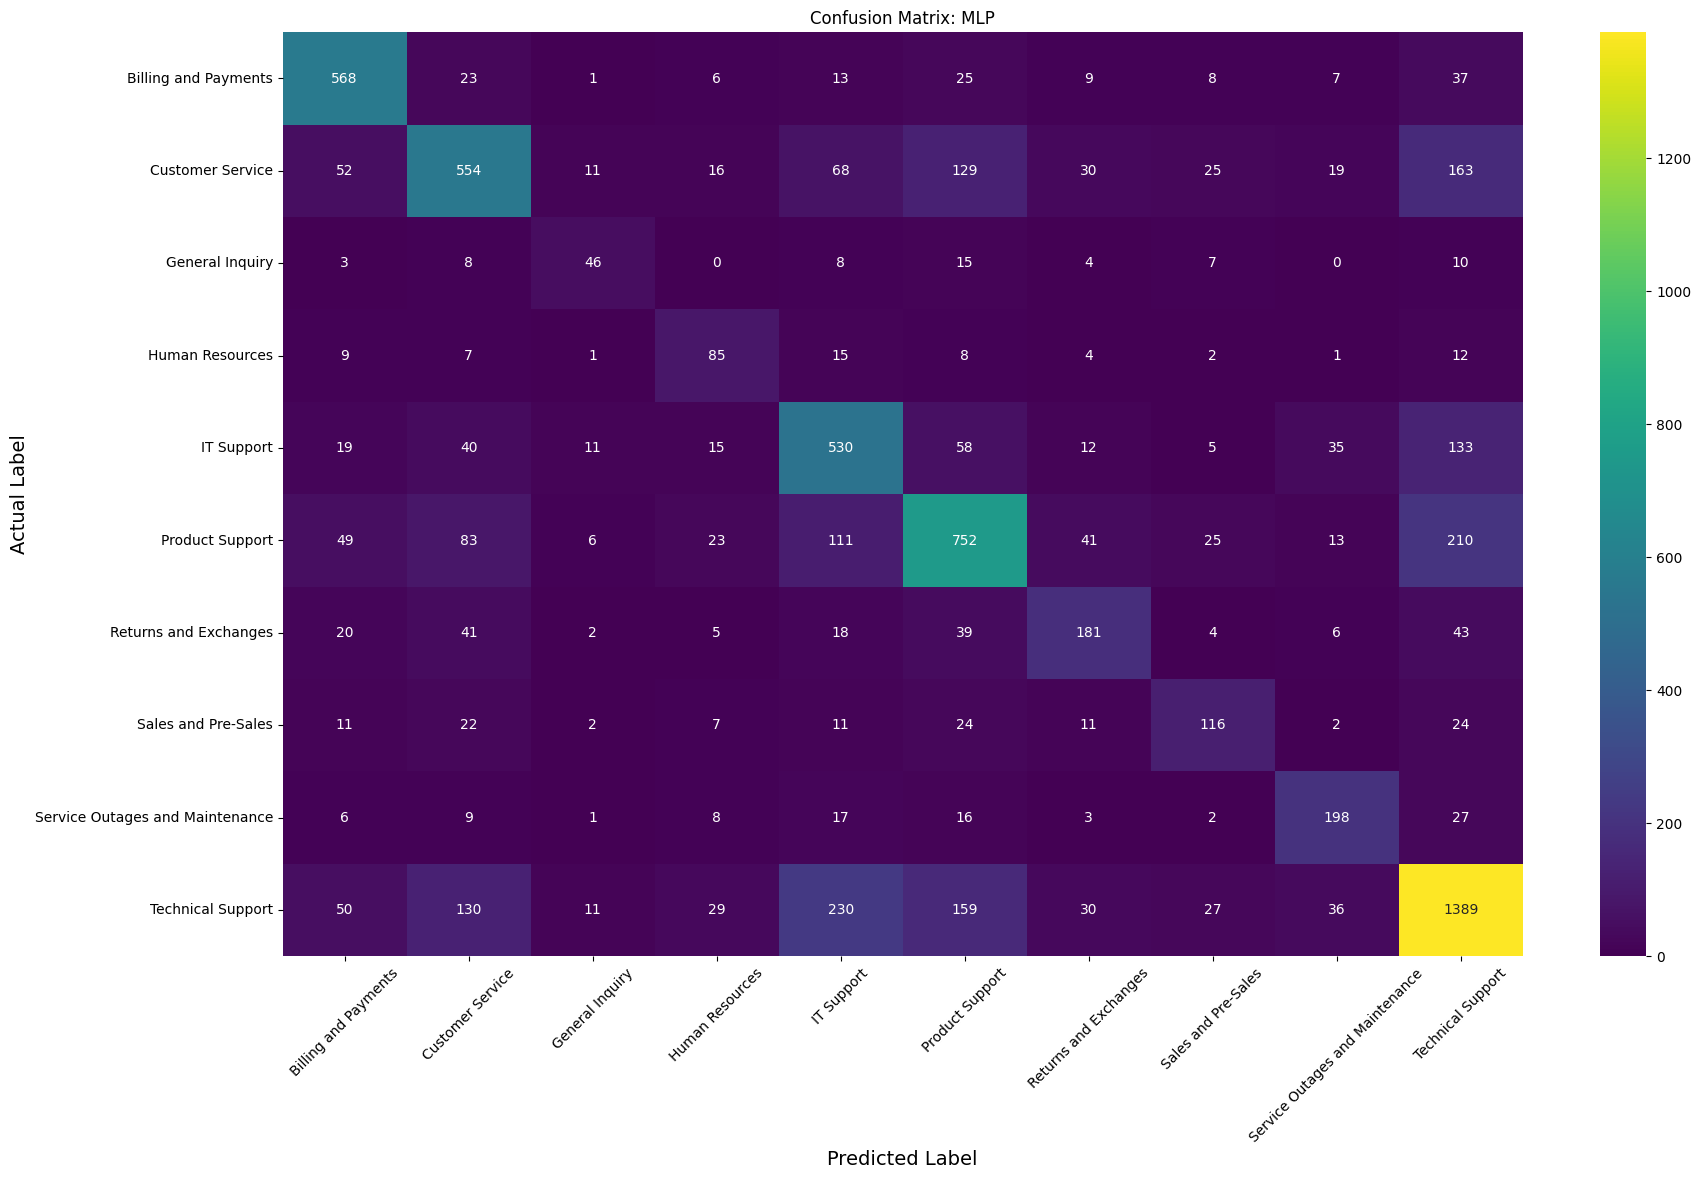


Classification Report Balanced Random Forest model:
              precision    recall  f1-score   support

           0       0.86      0.71      0.78       697
           1       0.45      0.44      0.44      1067
           2       0.14      0.80      0.24       101
           3       0.46      0.70      0.55       144
           4       0.55      0.45      0.50       858
           5       0.60      0.33      0.42      1313
           6       0.42      0.55      0.48       359
           7       0.28      0.67      0.40       230
           8       0.37      0.78      0.51       287
           9       0.61      0.50      0.55      2091

    accuracy                           0.50      7147
   macro avg       0.48      0.59      0.49      7147
weighted avg       0.56      0.50      0.51      7147



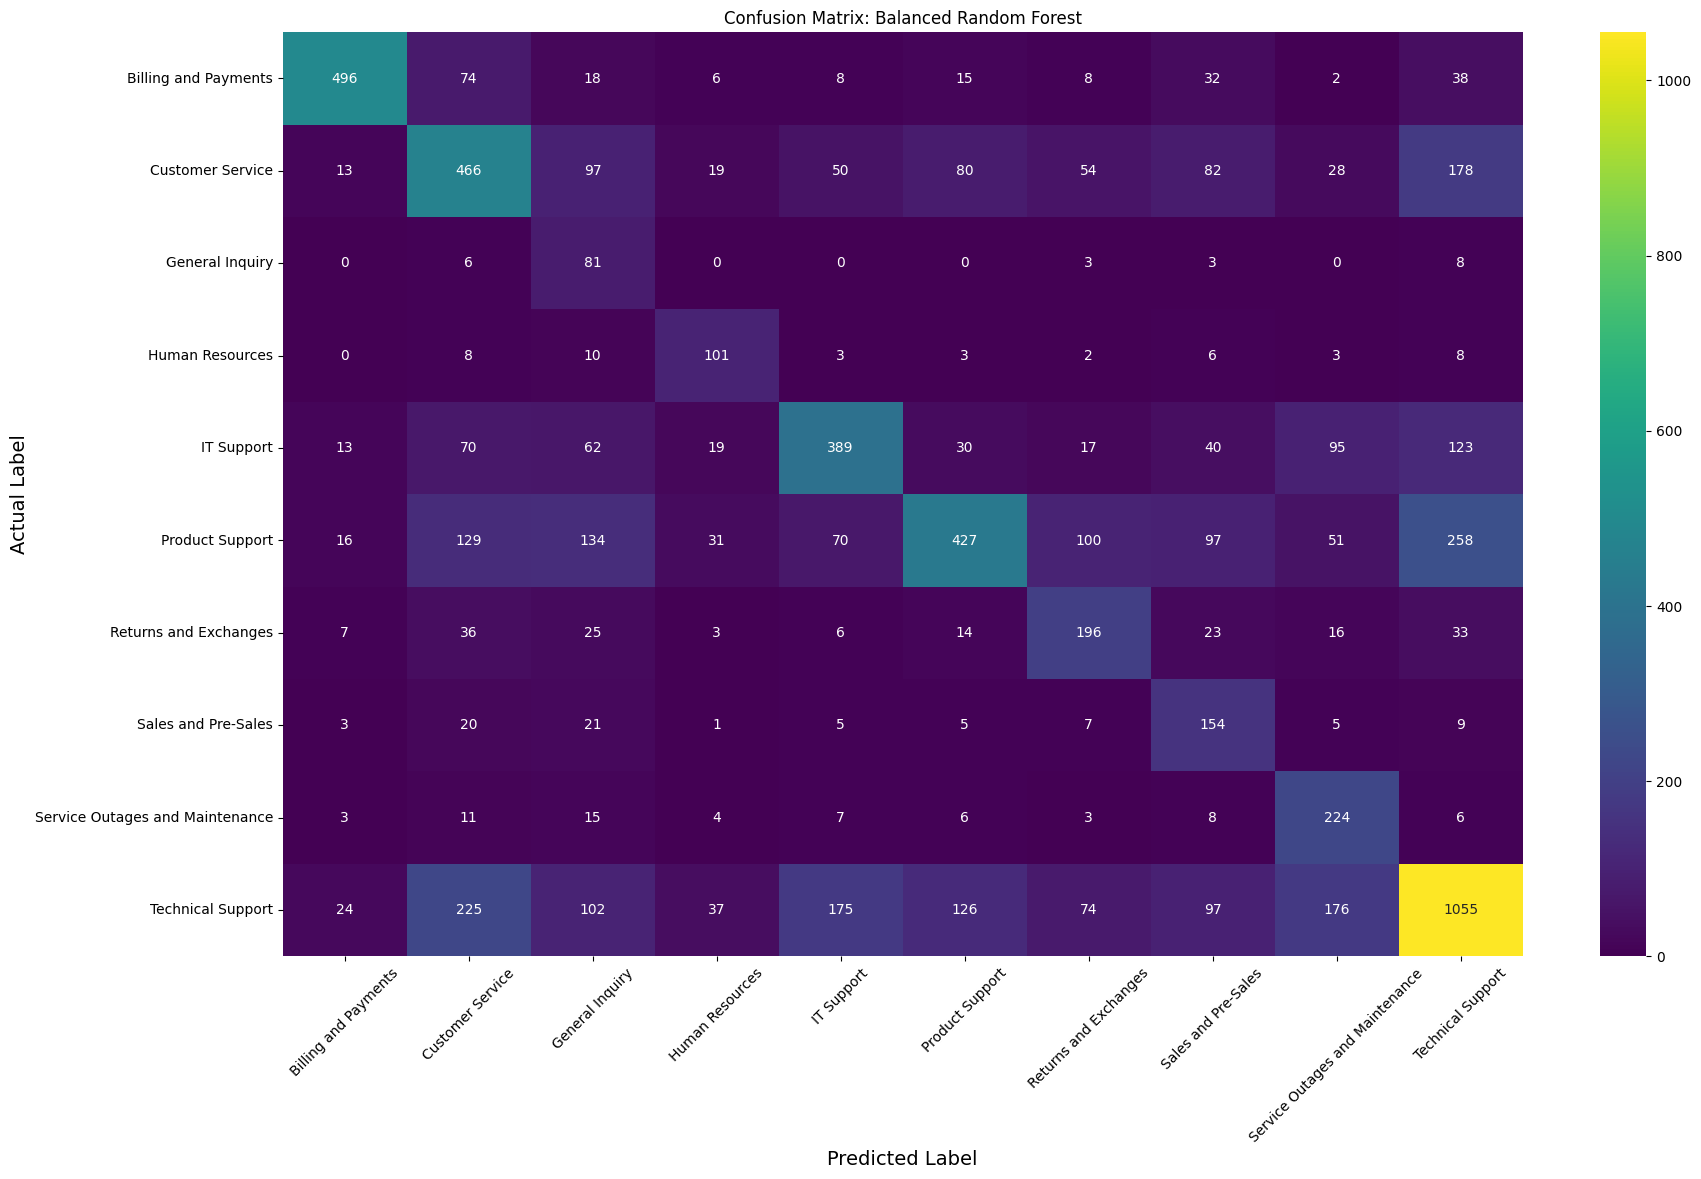

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
class_names = le.classes_
for name, model in models.items():
    model.fit(train_X, train_y)
    y_pred = model.predict(test_X)
    print(f"\nClassification Report {name} model:")
    print(classification_report(test_y, y_pred))

    cm = confusion_matrix(test_y, y_pred)
    plt.figure(figsize=(20, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',xticklabels=class_names,yticklabels=class_names)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

# Training model for classifying priority

In [ ]:
le1 = LabelEncoder()
#df_X = data1
data_queue = pd.DataFrame(df_y_encoded,columns=["queue"])
df_X = pd.concat([data1, data_queue], axis=1)
df_y = data["priority"]
df_y_encoded1 = le1.fit_transform(df_y)
train1_X,test1_X,train1_y,test1_y = train_test_split(df_X,df_y_encoded1, test_size= 0.25,shuffle=True, stratify=df_y_encoded1)

In [ ]:
models1 = {
    "KNN": KNeighborsClassifier(n_neighbors=2, weights='distance', metric="manhattan"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1,class_weight='balanced'),
    "Naive Bayes": GaussianNB(),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.01, random_state=42,class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.01, random_state=42, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(iterations=100, learning_rate=0.01, depth=8, random_state=42, verbose=0, auto_class_weights='Balanced'),
    "MLP": MLPClassifier(hidden_layer_sizes=(120,100),max_iter=100,activation="relu",solver="adam",random_state=42),
    "Balanced Random Forest": BalancedRandomForestClassifier(n_estimators=700,min_samples_leaf=2, sampling_strategy="auto")
                                            }


Classification Report KNN model:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      2795
           1       0.84      0.84      0.84      1473
           2       0.88      0.86      0.87      2879

    accuracy                           0.87      7147
   macro avg       0.86      0.86      0.86      7147
weighted avg       0.87      0.87      0.87      7147



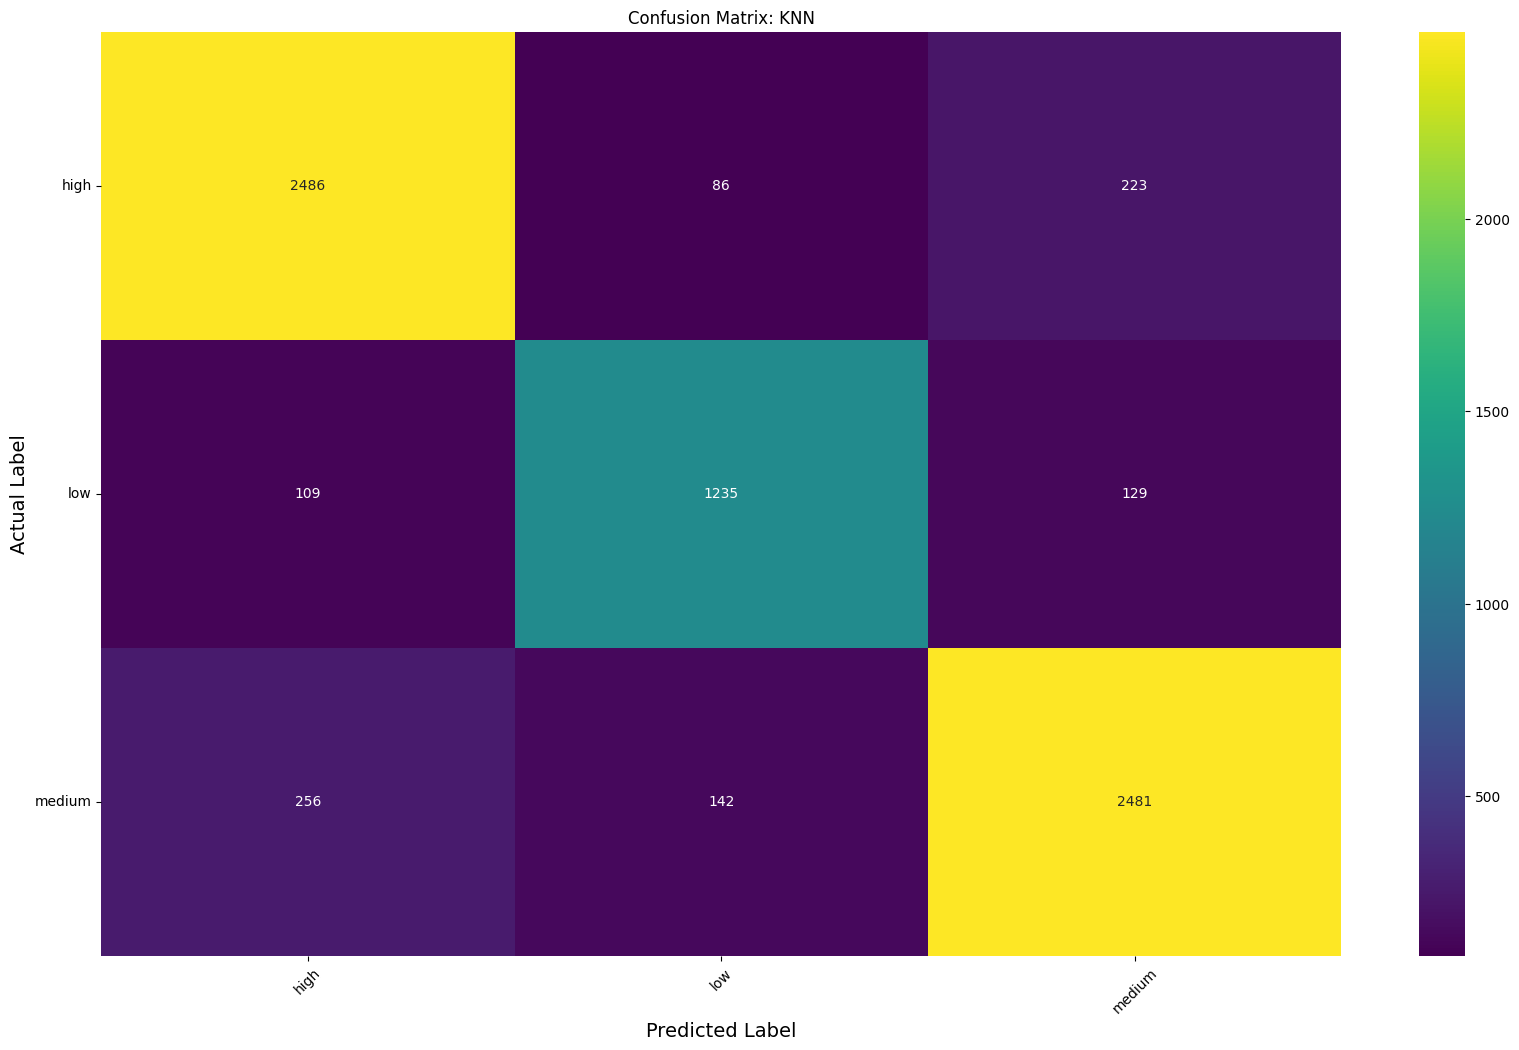


Classification Report Random Forest model:
              precision    recall  f1-score   support

           0       0.68      0.69      0.68      2795
           1       0.62      0.52      0.57      1473
           2       0.63      0.67      0.65      2879

    accuracy                           0.65      7147
   macro avg       0.64      0.63      0.63      7147
weighted avg       0.65      0.65      0.65      7147



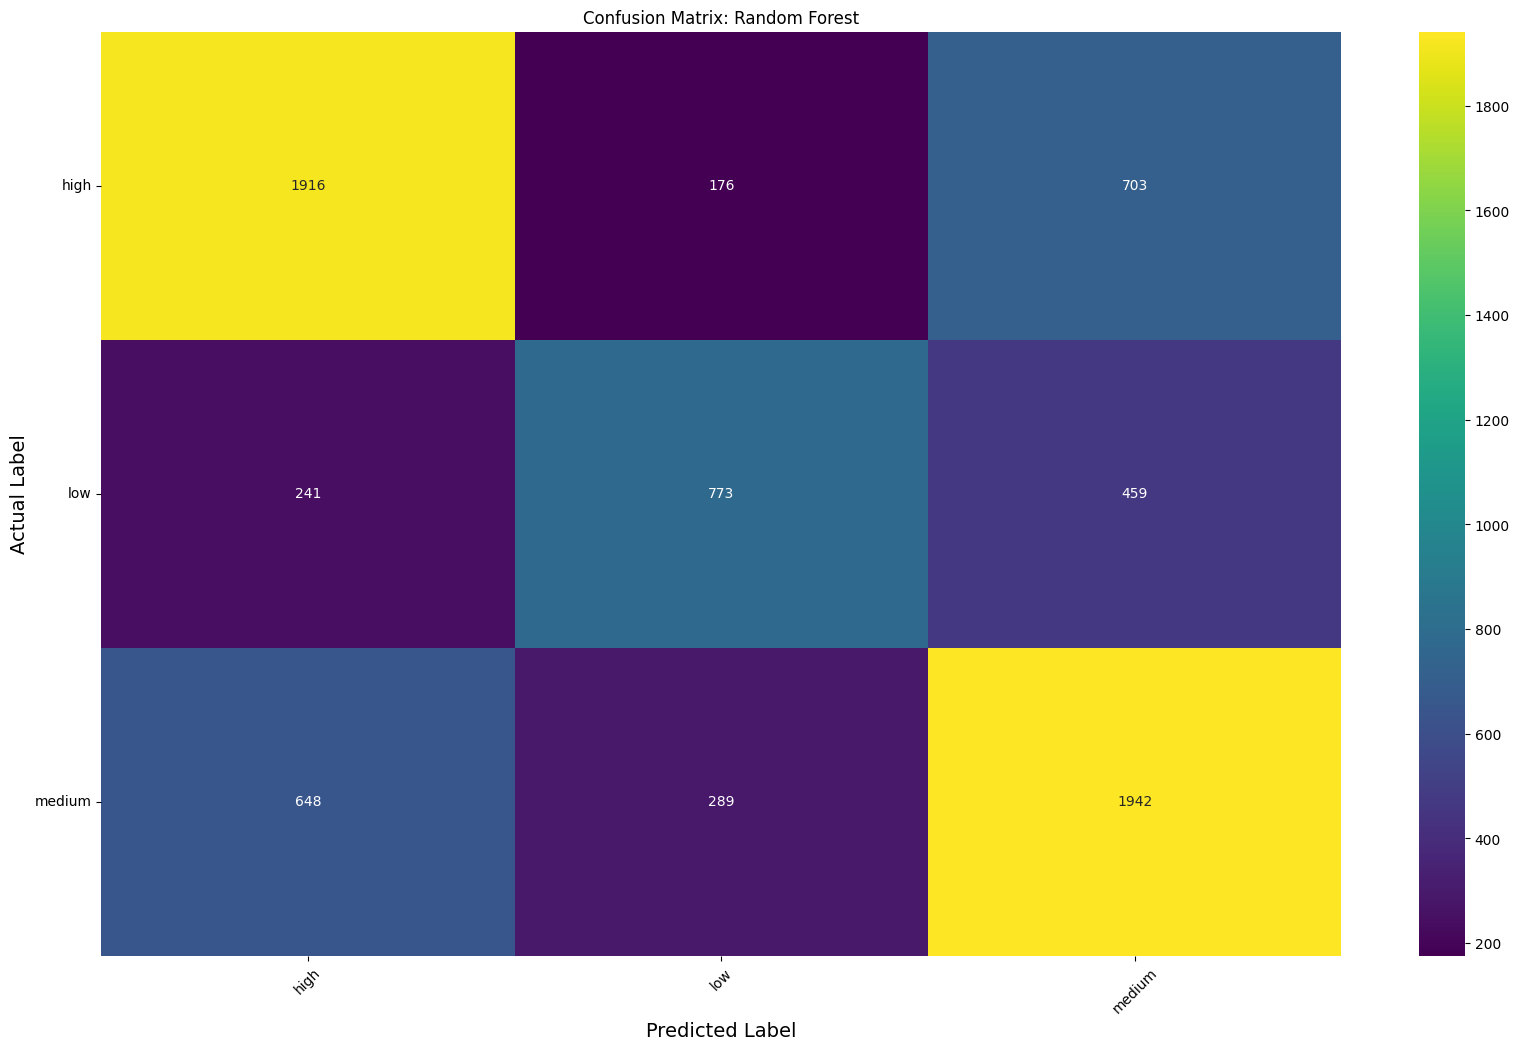


Classification Report Naive Bayes model:
              precision    recall  f1-score   support

           0       0.47      0.56      0.51      2795
           1       0.26      0.40      0.31      1473
           2       0.43      0.23      0.30      2879

    accuracy                           0.40      7147
   macro avg       0.39      0.40      0.38      7147
weighted avg       0.41      0.40      0.39      7147



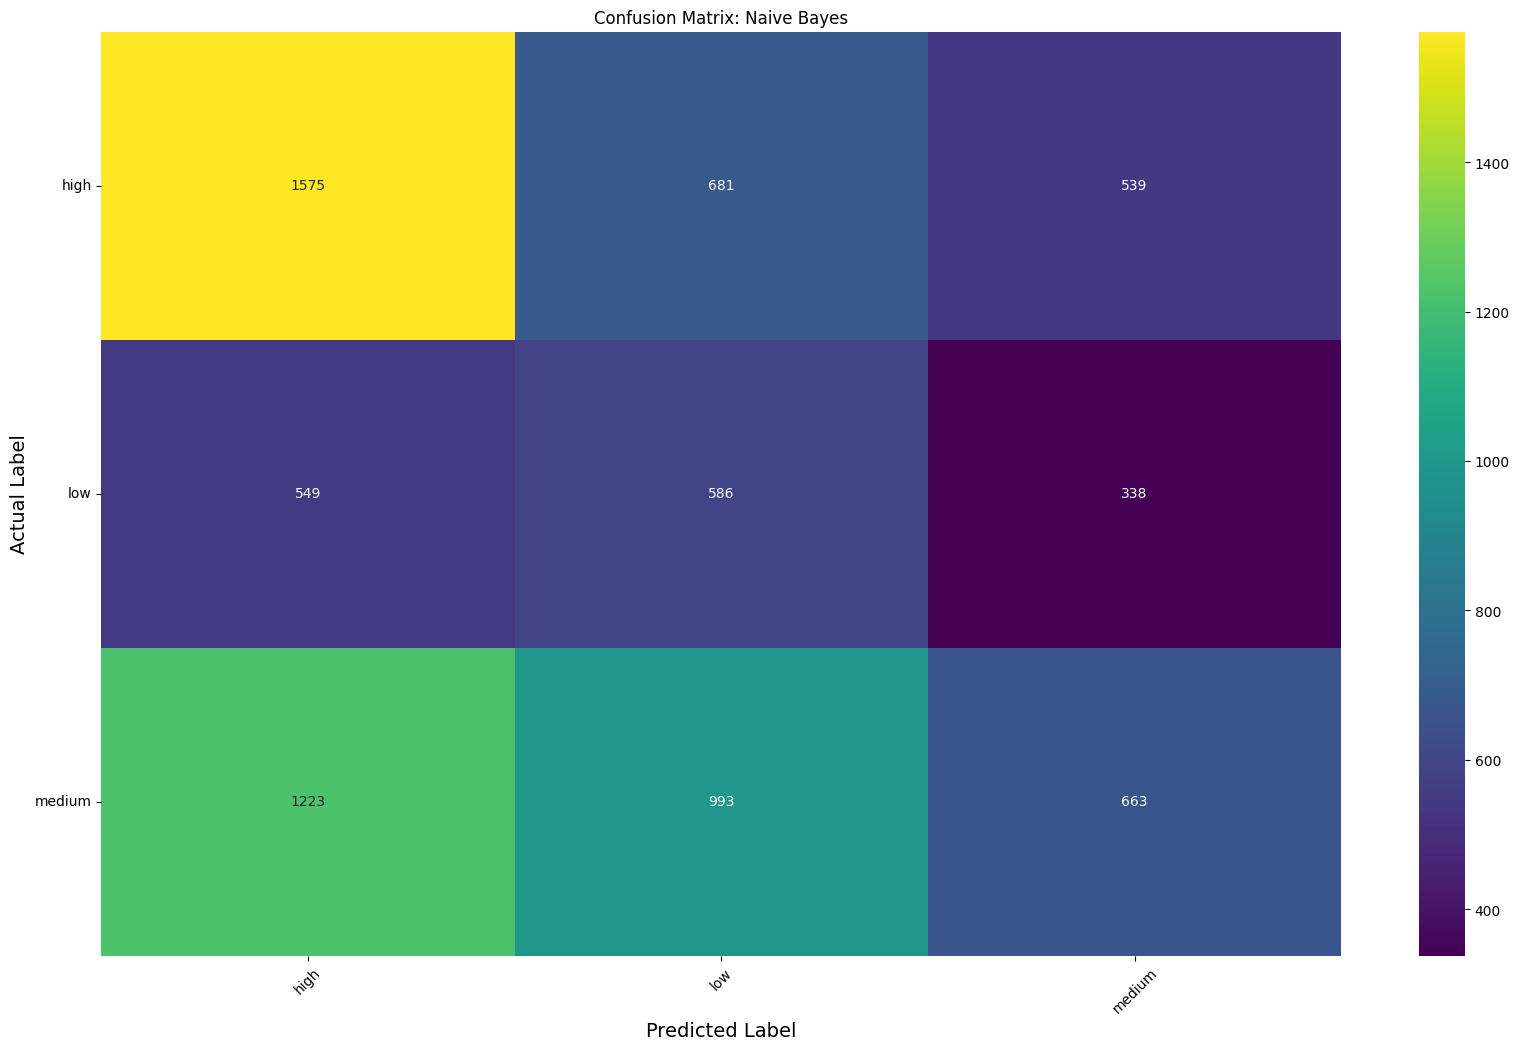

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.387561 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195850
[LightGBM] [Info] Number of data points in the train set: 21440, number of used features: 769
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

Classification Report LightGBM model:
              precision    recall  f1-score   support

           0       0.62      0.66      0.64      2795
           1       0.40      0.62      0.49      1473
           2       0.57      0.38      0.46      2879

    accuracy                           0.54      7147
   macro avg       0.53      0.55      0.53      7147
weighted avg       0.56      0.54      0.53      7147



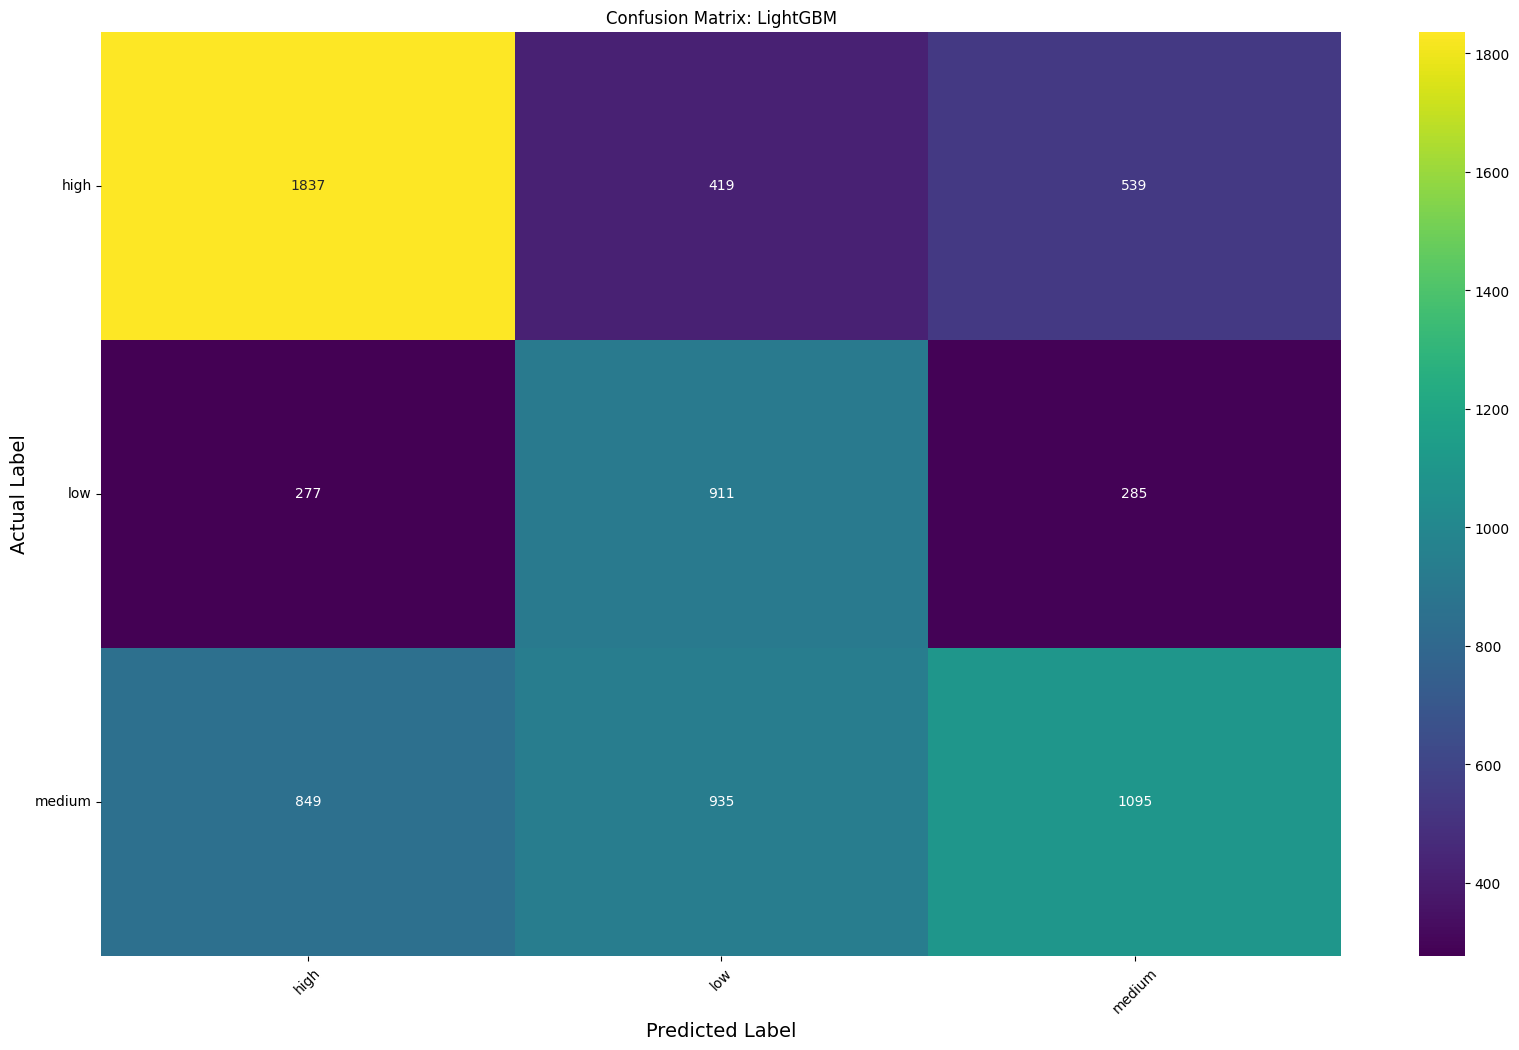


Classification Report XGBoost model:
              precision    recall  f1-score   support

           0       0.62      0.65      0.64      2795
           1       0.89      0.06      0.11      1473
           2       0.50      0.72      0.59      2879

    accuracy                           0.56      7147
   macro avg       0.67      0.48      0.45      7147
weighted avg       0.63      0.56      0.51      7147



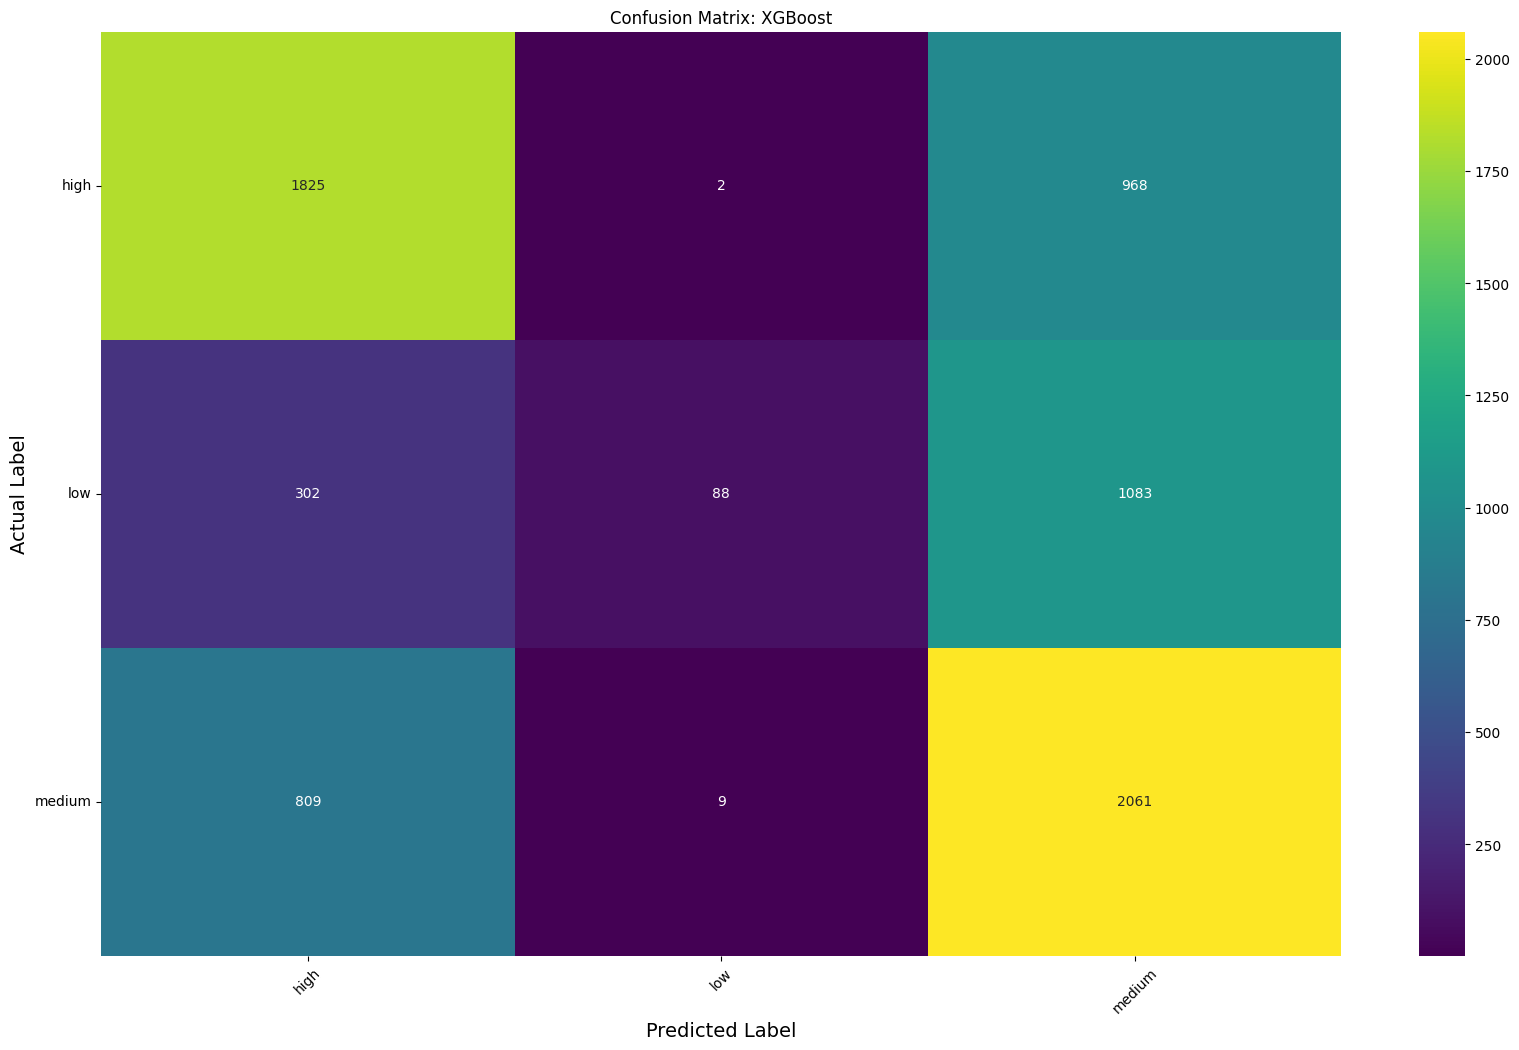


Classification Report CatBoost model:
              precision    recall  f1-score   support

           0       0.62      0.55      0.58      2795
           1       0.35      0.66      0.46      1473
           2       0.52      0.34      0.41      2879

    accuracy                           0.49      7147
   macro avg       0.50      0.52      0.48      7147
weighted avg       0.52      0.49      0.49      7147



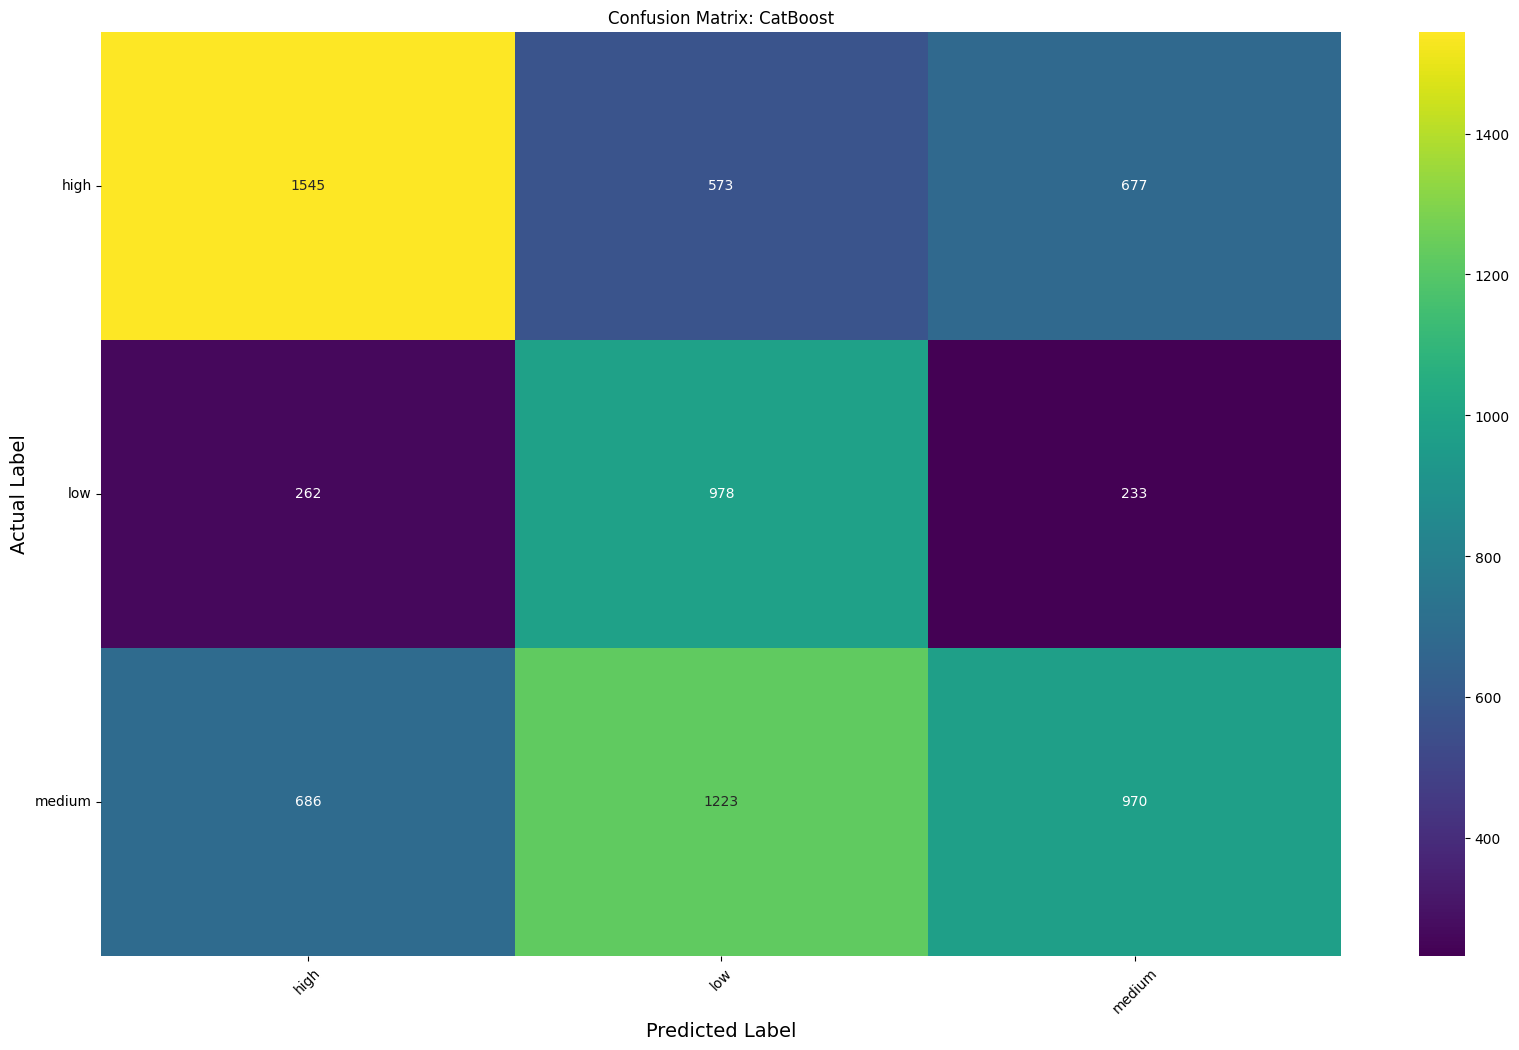

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



Classification Report MLP model:
              precision    recall  f1-score   support

           0       0.78      0.79      0.79      2795
           1       0.70      0.69      0.70      1473
           2       0.75      0.75      0.75      2879

    accuracy                           0.75      7147
   macro avg       0.75      0.74      0.74      7147
weighted avg       0.75      0.75      0.75      7147



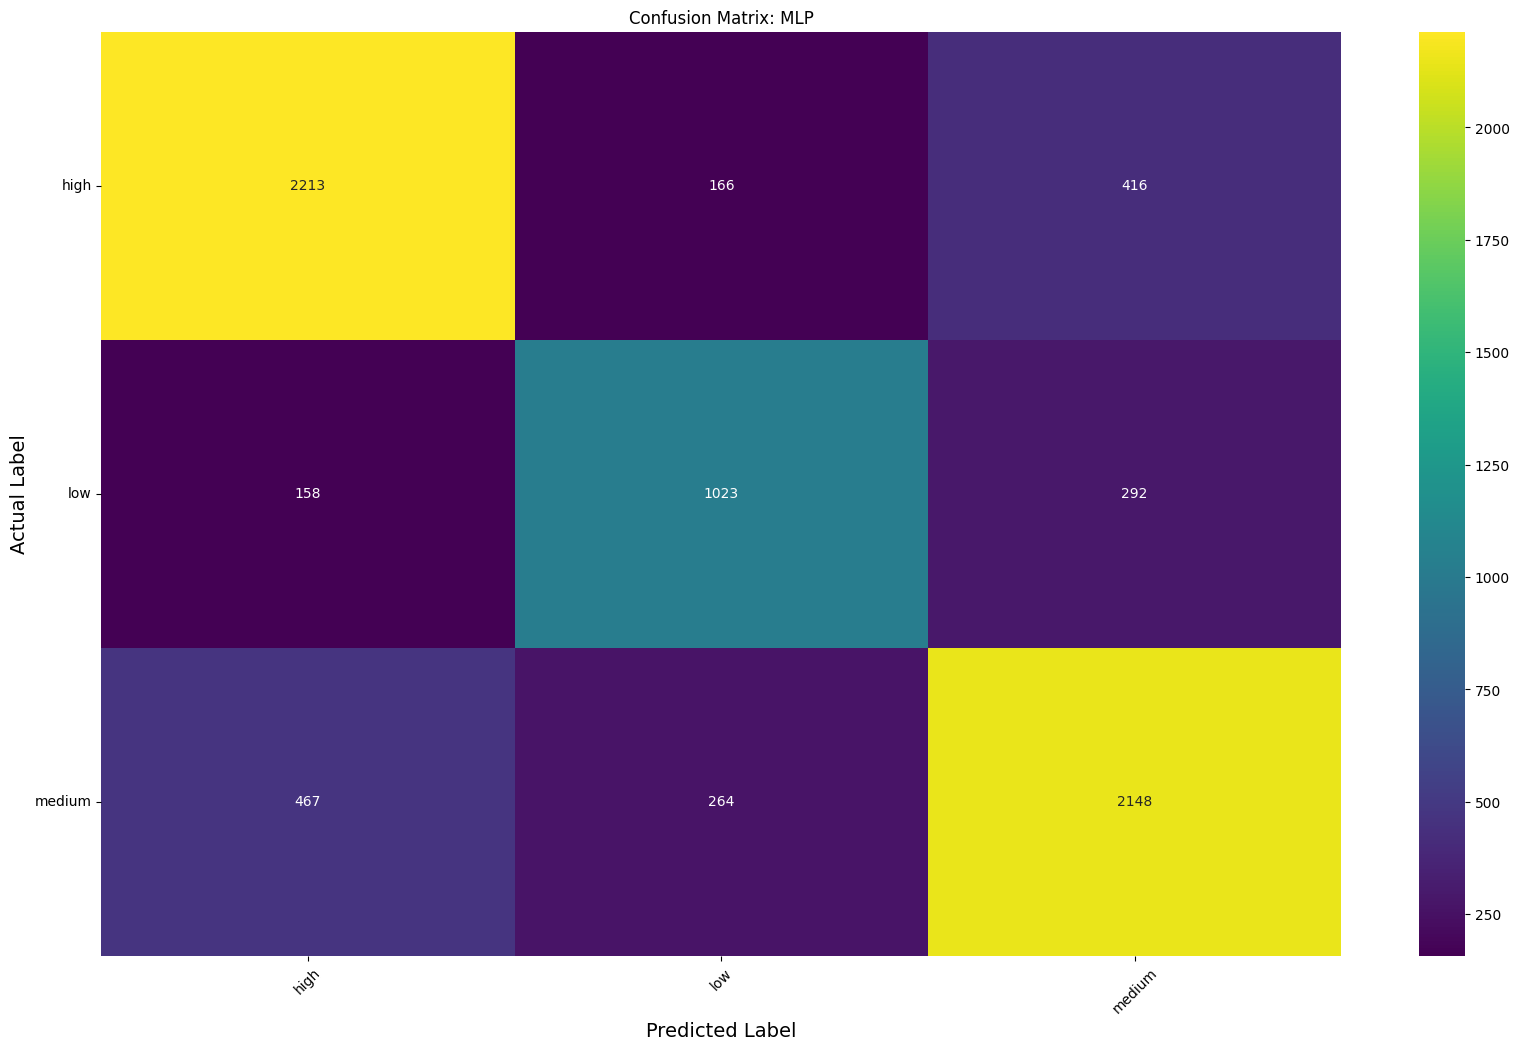


Classification Report Balanced Random Forest model:
              precision    recall  f1-score   support

           0       0.80      0.71      0.75      2795
           1       0.47      0.91      0.62      1473
           2       0.85      0.54      0.66      2879

    accuracy                           0.68      7147
   macro avg       0.71      0.72      0.68      7147
weighted avg       0.75      0.68      0.69      7147



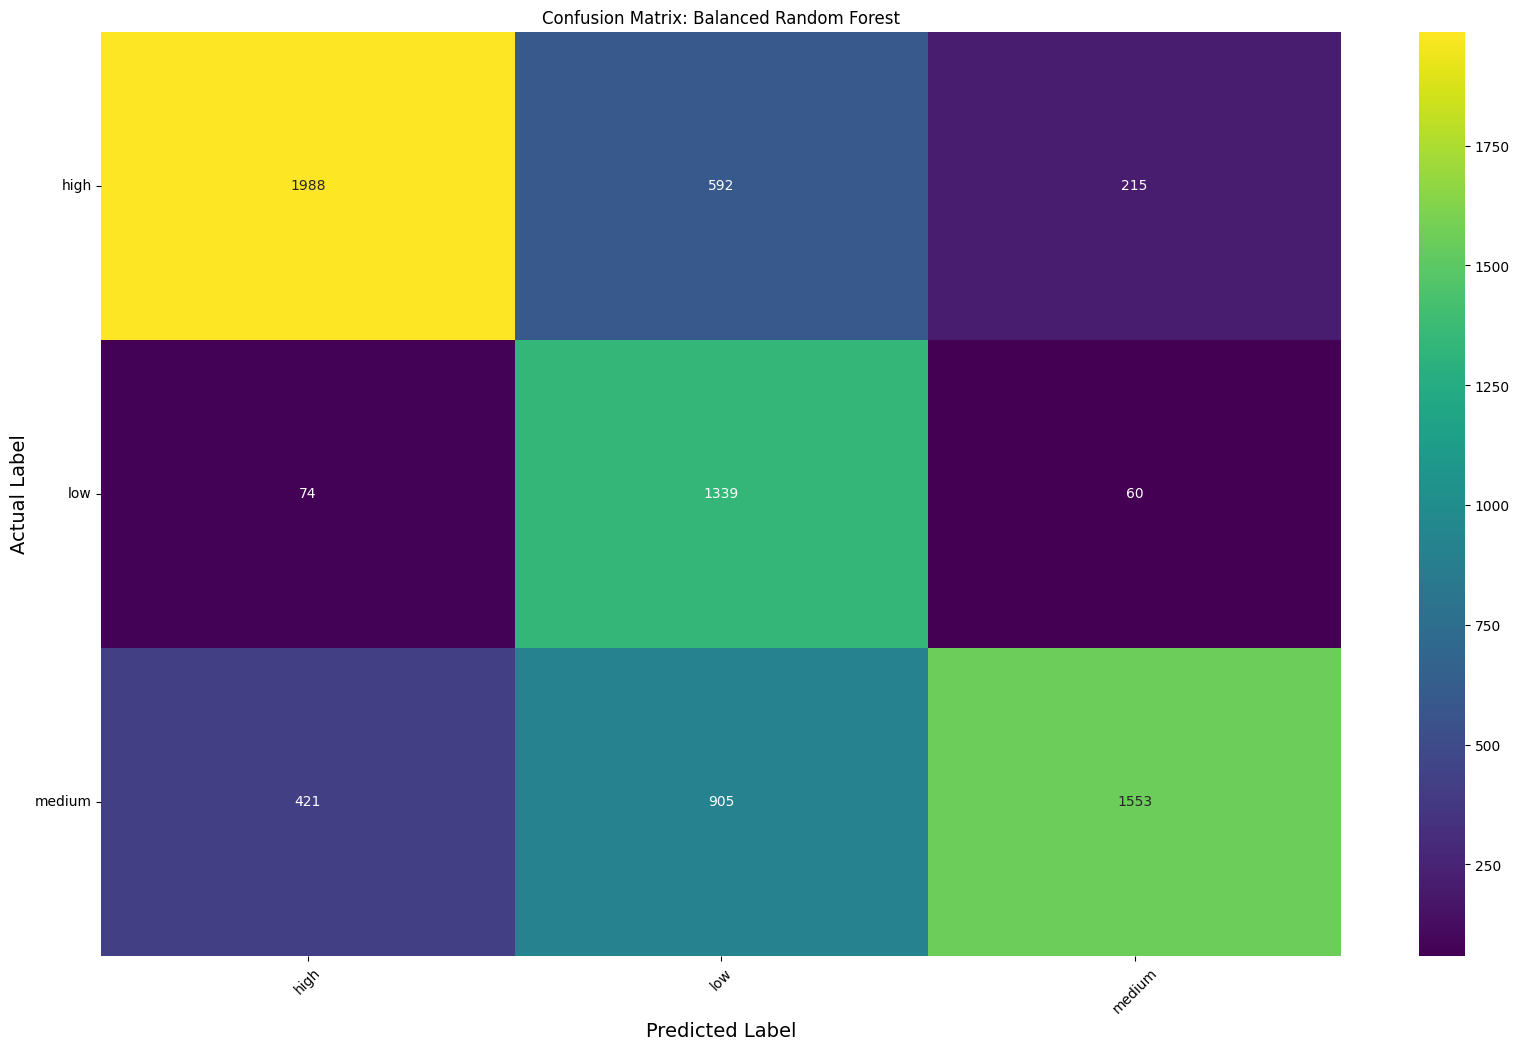

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
class_names1 = le1.classes_
for name, model in models1.items():
    model.fit(train1_X, train1_y)
    y_pred = model.predict(test1_X)
    print(f"\nClassification Report {name} model:")
    print(classification_report(test1_y, y_pred))

    cm = confusion_matrix(test1_y, y_pred)
    plt.figure(figsize=(20, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',xticklabels=class_names1,yticklabels=class_names1)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

In [ ]:
model_queue = models['KNN']
model_priority = models1['KNN']
priority_mapping = {'low':0, 'medium':0.5, 'high':1}
sentiment_mapping = {'positive':0,'neutral':0.5,'negative':1}
classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")
model = SentenceTransformer('all-mpnet-base-v2')
priority_weight = 0.6
sentiment_weight = 0.4

def get_sentiment(text):
    result = classifier(text)[0]
    return pd.Series([result["label"], result["score"]])

def run_simulation(text):
    embedding = model.encode(text)
    X_input = pd.DataFrame([embedding], columns=data1.columns)
    queue_idx = model_queue.predict(X_input)
    X_input1 = X_input.copy()
    X_input1['queue'] = queue_idx
    priority_idx = model_priority.predict(X_input1)
    queue_label = le.inverse_transform(queue_idx)[0]
    priority_label = le1.inverse_transform(priority_idx)[0]
    label, score = get_sentiment(text)
    f_priority = priority_mapping.get(priority_label.lower(), 0)
    f_sentiment = sentiment_mapping.get(label.lower(), 0)
    final_score = (priority_weight * f_priority) + (sentiment_weight * f_sentiment)
    if final_score > 0.5:
        result = print(f"""ACTION: Prioritize to Human Agent\n
Queue: {queue_label}\n
Priority Level: {priority_label}\n
Sentiment: {label} ({score:.2f})\n
Final Priority Score: {final_score:.2f}""")
    else:
        result = print(f"""ACTION: Handled by AI Chatbot\n
Sentiment: {label} ({score:.2f})\n
Final Priority Score: {final_score:.2f}""")
    return result

In [ ]:
import random
comment = data.loc[random.choice(data.index),"body_en"]
print(comment)
run_simulation(comment)

Unauthorized access attempt to the hospital IT systems was detected, initially via the Smart-Tracker connection. Due to a vulnerability in Android 12, fresh software updates have been applied to multiple devices. Antivirus measures have been updated, and a security check has been conducted on the affected products, but the issue persists. We appreciate your prompt assistance in resolving this problem to ensure the integrity of our systems.
ACTION: Handled by AI Chatbot

Sentiment: neutral (0.67)

Final Priority Score: 0.50


In [ ]:
comment = data.loc[random.choice(data.index),"body_en"]
print(comment)
run_simulation(comment)

Users are reporting recurring issues with data queries on the SaaS platform. There are compatibility issues with Node.js, MySQL, and Magento. Services have been restarted and relevant packages have been updated, but the problem persists.
ACTION: Prioritize to Human Agent

Queue: Technical Support

Priority Level: medium

Sentiment: negative (0.72)

Final Priority Score: 0.70


In [ ]:
comment = data.loc[random.choice(data.index),"body_en"]
print(comment)
run_simulation(comment)

A critical system error occurred while using Google Cloud Platform for data analysis. The error might be due to conflicting software versions or network issues. We have restarted the affected applications and cleared the cache, but the problem persists. We would be glad to help resolve this issue as soon as possible. Could you please provide more details on the error message and the steps you have already taken to resolve it? Alternatively, we can arrange a call to discuss further. Are you available today at <tel_num>? If not, please provide a time that works for you to ensure we can contact the account handler.
ACTION: Handled by AI Chatbot

Sentiment: neutral (0.66)

Final Priority Score: 0.50


In [ ]:
import joblib
joblib.dump(model_queue, 'model_knn_queue.joblib')
joblib.dump(model_priority, 'model_knn_priority.joblib')

['model_knn_priority.joblib']